
# Project Checkpoint 2: Research Question Formation
**Dataset:** MovieLens 25M  
**Course:** Data Mining & Analysis  

This notebook defines the research questions and methodological plan for the semester project.  
It builds on the dataset selection and EDA performed in Checkpoint 1, which explored the MovieLens 25M dataset.

---



## Dataset Recap (from Checkpoint 1)

The **MovieLens 25M dataset** contains 25 million user ratings for movies.

Key tables:

- **ratings.csv** – userId, movieId, rating, timestamp
- **movies.csv** – movieId, title, genres
- **tags.csv** – user tags on movies

### Why this dataset fits the course

The dataset naturally supports transaction-style analysis, where each user’s watched or rated movies can be treated as a basket of items.

This makes the dataset well suited for:

- Frequent itemset mining
- Association rule mining
- Sequential pattern mining

These methods allow us to discover patterns in viewing behavior.


In [2]:
# Dataset download
import os
import requests
import zipfile

def hydrate_movielens():
    """
    Downloads and extracts the MovieLens 25M dataset.
    """
    url = "https://files.grouplens.org/datasets/movielens/ml-25m.zip"
    data_dir = "../data"
    zip_path = os.path.join(data_dir, "ml-25m.zip")
    extract_path = os.path.join(data_dir, "ml-25m")

    # 1. Create data directory if it doesn't exist
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)
        print(f"Created directory: {data_dir}")

    # 2. Download the dataset
    if not os.path.exists(zip_path):
        print("Downloading MovieLens 25M dataset (approx. 250MB)...")
        response = requests.get(url, stream=True)
        if response.status_code == 200:
            with open(zip_path, 'wb') as f:
                for chunk in response.iter_content(chunk_size=1024):
                    if chunk:
                        f.write(chunk)
            print("Download complete.")
        else:
            print(f"Failed to download. Status code: {response.status_code}")
            return
    else:
        print("Zip file already exists. Skipping download.")

    # 3. Extract the dataset
    if not os.path.exists(extract_path):
        print("Extracting files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Extraction complete.")
    else:
        print("Dataset already extracted.")


hydrate_movielens()

Created directory: ../data
Download complete.
Extracting files...
Extraction complete.


In [3]:
# Environment Setup & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Checking for file existence before loading
DATA_PATH = '../data/ml-25m/'
files_needed = ['ratings.csv', 'movies.csv']

for file in files_needed:
    if not os.path.exists(DATA_PATH + file):
        print(f"⚠️ Warning: {file} not found. Please ensure data is hydrated in the /data folder.")

# Loading only necessary columns to save memory (25M rows is ~650MB in RAM)
ratings = pd.read_csv(DATA_PATH + 'ratings.csv')
movies = pd.read_csv(DATA_PATH + 'movies.csv')

print(f"Dataset Loaded: {len(ratings):,} ratings and {len(movies):,} movies.")

Dataset Loaded: 25,000,095 ratings and 62,423 movies.


## Additional EDA for Method Feasibility

To ensure that frequent pattern mining is feasible, we examine:

- Number of ratings
- Number of unique users
- Number of unique movies
- Distribution of movies watched per user

These statistics help determine reasonable support thresholds and computational limits.

Number of ratings: 25000095
Unique users: 162541
Unique movies: 59047


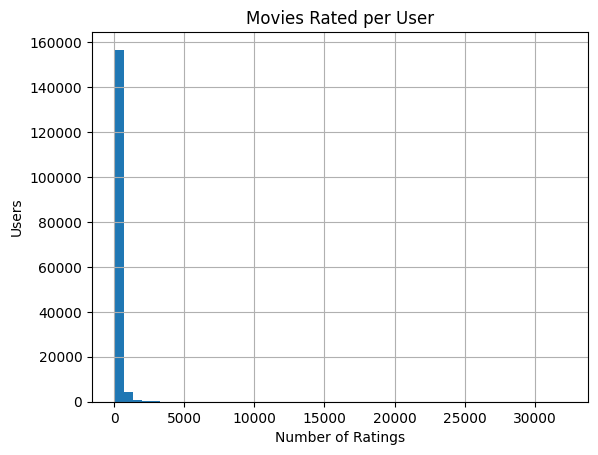

In [4]:
print("Number of ratings:", len(ratings))
print("Unique users:", ratings.userId.nunique())
print("Unique movies:", ratings.movieId.nunique())

user_activity = ratings.groupby("userId").size()

plt.figure()
user_activity.hist(bins=50)
plt.title("Movies Rated per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Users")
plt.show()


# Research Questions

The project defines three research questions.

At least two use course techniques, and one uses an external technique.



### RQ1
**What frequent groups of movies tend to appear together in user viewing histories?**

Task Type: Frequent Itemset Mining  
Course Algorithm: FP-Growth / Apriori

Evaluation Criteria:

- Support
- Pattern interpretability
- Number of discovered itemsets


### RQ2
**How do confidence and lift differ when evaluating association rules between movies?**

Task Type: Association Rule Mining  
Course Algorithm: Apriori + Association Rules

Evaluation Criteria:

- Confidence
- Lift
- Rule coverage


### RQ3 (External Method)

**Do sequential viewing patterns reveal structures that unordered itemsets miss?**

Task Type: Sequential Pattern Mining  
External Algorithm: PrefixSpan

Evaluation Criteria:

- Sequential support
- Pattern diversity
- Interpretability



# RQ-to-Method Mapping


In [5]:

mapping = pd.DataFrame([
    ["RQ1","Frequent Itemset Mining","FP-Growth / Apriori","Course","Support"],
    ["RQ2","Association Rules","Apriori","Course","Confidence, Lift"],
    ["RQ3","Sequential Pattern Mining","PrefixSpan","External","Sequential Support"]
], columns=["RQ","Task Type","Algorithm","Course/External","Evaluation Metric"])

mapping


,RQ,Task Type,Algorithm,Course/External,Evaluation Metric
0,RQ1,Frequent Itemset Mining,FP-Growth / Apriori,Course,Support
1,RQ2,Association Rules,Apriori,Course,"Confidence, Lift"
2,RQ3,Sequential Pattern Mining,PrefixSpan,External,Sequential Support


# Methodological Planning

### Course Algorithms

- FP-Growth
- Apriori
- Association Rules

These algorithms will identify common movie co‑occurrence patterns.

### External Algorithm

PrefixSpan will be used to detect sequential viewing patterns.

### Evaluation

Patterns will be evaluated using:

- Support
- Confidence
- Lift
- Pattern diversity

### Baseline

Baseline approach will consist of mining only high-support itemsets, ignoring sequential order.

### Risks

- Dataset scale may require filtering low‑frequency movies.
- Sequential pattern mining may be computationally expensive.


# Initial Method Feasibility Test

This small test verifies that transaction baskets can be created for frequent itemset mining.


In [6]:
# Create simple transaction baskets
baskets = ratings.groupby("userId")["movieId"].apply(list)

print("Example basket:")
print(baskets.iloc[0][:10])

Example basket:
[296, 306, 307, 665, 899, 1088, 1175, 1217, 1237, 1250]


## Collaboration Declaration


1. **Web Sources:**  
- MovieLens Dataset Documentation: https://grouplens.org/datasets/movielens/  

2. **AI Tools:**  
- ChatGPT: Used for outlining research question structure, methodological planning, and improving code clarity.

3. **Citations:**  
- Harper & Konstan (2015): The MovieLens Datasets: History and Context.
